# 国泰君安 191 因子回测框架 (Alpha 001 & Alpha 101)
该 Notebook 实现了国泰君安 191 因子集的两个代表性因子：Alpha 001 和 Alpha 101 的回测。

**因子公式说明：**
1. **Alpha 101**: `(close - open) / (high - low + 0.001)`
   *   物理意义：反映当日走势的强弱，衡量日内震荡后的收盘相对位置。
2. **Alpha 001**: `-1 * CORR(RANK(DELTA(LOG(VOLUME), 1)), RANK((CLOSE - OPEN) / OPEN), 6)`
   *   物理意义：结合了成交量变化率排名与日内涨幅排名的负相关性，属于价量复合因子。

**回测规范：**
*   初始本金：50,000 元
*   调仓频率：每周（周五或周最后一个交易日）
*   持仓数量：10 只
*   手续费：佣金 0.025%（最低 5 元），过户费 0.001%，印花税 0.05%（仅卖出）
*   限制条件：涨跌停（+/- 9.3%）无法买入/卖出，缺失数据视为退市。

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_CSV = r"F:\self_quant\quant_gemini\csv\gtja_191_alphas_trades.csv"

INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10

print("正在读取全市场数据...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()
df.sort_values(by=['code', 'date'], inplace=True)

print(f"数据范围: {df['date'].min().date()} 至 {df['date'].max().date()}")

正在读取全市场数据...
数据范围: 2010-01-04 至 2026-03-20


In [14]:
print("正在计算前向收益率...")
df['fwd_ret_1d'] = df.groupby('code')['close'].shift(-1) / df['close'] - 1
df['fwd_ret_1w'] = df.groupby('code')['close'].shift(-5) / df['close'] - 1
df['fwd_ret_1m'] = df.groupby('code')['close'].shift(-20) / df['close'] - 1

# ==========================================
# 常用算子定义
# ==========================================
def RANK(series):
    """截面排名 (百分比)"""
    return series.rank(pct=True)

def DELTA(series, n):
    """差分"""
    return series.diff(n)

def DELAY(series, n):
    """滞后"""
    return series.shift(n)

def CORR(x, y, n):
    """时序滚动相关系数"""
    return x.rolling(n).corr(y)

def TSMAX(series, n):
    """时序滚动最大值"""
    return series.rolling(n).max()

def TSRANK(series, n):
    """时序滚动排名"""
    return series.rolling(n).apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1])

正在计算前向收益率...


In [15]:
def calculate_factors(df):
    print("开始计算 GTJA 191 因子...")
    
    # 过滤掉停牌和 ST 股票的数据来进行截面计算
    mask = (df['tradestatus'] == 1) & (df['isST'] == 0)
    temp_df = df[mask].copy()
    
    # --- Alpha 101 ---
    # (close - open) / (high - low + 0.001)
    temp_df['alpha_101'] = (temp_df['close'] - temp_df['open']) / (temp_df['high'] - temp_df['low'] + 0.001)
    
    # --- Alpha 001 ---
    # -1 * CORR(RANK(DELTA(LOG(VOLUME), 1)), RANK((CLOSE - OPEN) / OPEN), 6)
    temp_df['log_vol'] = np.log(temp_df['volume'] + 1)
    temp_df['delta_log_vol'] = temp_df.groupby('code')['log_vol'].diff(1)
    temp_df['ret_intra'] = (temp_df['close'] - temp_df['open']) / temp_df['open']
    
    # 截面排名
    temp_df['rank_delta_vol'] = temp_df.groupby('date')['delta_log_vol'].rank(pct=True)
    temp_df['rank_ret_intra'] = temp_df.groupby('date')['ret_intra'].rank(pct=True)
    
    # 时序相关系数
    # 注意：CORR 需要在 groupby('code') 后进行
    temp_df['alpha_001'] = -1 * temp_df.groupby('code').apply(
        lambda x: x['rank_delta_vol'].rolling(6).corr(x['rank_ret_intra'])
    ).reset_index(level=0, drop=True)
    
    # 将计算结果赋值回主表
    df.loc[mask, 'alpha_101'] = temp_df['alpha_101']
    df.loc[mask, 'alpha_001'] = temp_df['alpha_001']
    
    return df

df = calculate_factors(df)

# 选择 Alpha 001 作为主要回测因子
df['factor'] = df['alpha_001']

# 提取调仓日 (每周最后一个交易日)
df['year_week'] = df['date'].dt.to_period('W')
trade_dates = sorted(df.groupby('year_week')['date'].max().unique().tolist())
print(f"因子计算完成。调仓日数量: {len(trade_dates)}")

开始计算 GTJA 191 因子...
因子计算完成。调仓日数量: 829


In [16]:
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {} # {code: {'volume': v, 'price': p}}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            stock_value += pos['volume'] * price
        return self.cash + stock_value

accounts = {f"Group_{i+1}": Account(INITIAL_CASH) for i in range(5)}
print("开始五分组调仓回测...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    if daily_data.empty: continue
    
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()
    
    # 选股池：过滤停牌、ST 和 因子缺失
    valid_pool = daily_data[(daily_data['tradestatus'] == 1) & (daily_data['isST'] == 0)].copy()
    valid_pool = valid_pool.dropna(subset=['factor'])
    
    if valid_pool.empty: continue
    
    # 五分组 (Group 1 因子最高)
    try:
        valid_pool['quintile'] = pd.qcut(valid_pool['factor'].rank(method='first'), 5, 
                                        labels=['Group_5', 'Group_4', 'Group_3', 'Group_2', 'Group_1'])
    except:
        continue

    for group_name, account in accounts.items():
        # 记录当前总资产
        asset = account.get_total_asset(current_prices)
        account.history_assets.append({'date': date, 'total_asset': asset})
        
        # 目标持仓 (因子得分最高的 10 只)
        group_stocks = valid_pool[valid_pool['quintile'] == group_name]
        target_codes = group_stocks.sort_values(by='factor', ascending=False).head(TARGET_STOCK_NUM).index.tolist()
        
        # 1. 卖出逻辑
        current_holdings = list(account.positions.keys())
        for code in current_holdings:
            if code not in daily_data.index: # 退市
                del account.positions[code]
                continue
            
            if code not in target_codes:
                is_trading = status_dict.get(code, 0) == 1
                pct_chg = pct_chg_dict.get(code, 0)
                # 跌停无法卖出 (限制 -9.3%)
                if is_trading and pct_chg > -9.3:
                    sell_price = current_prices[code]
                    vol = account.positions[code]['volume']
                    fee, amount = calculate_fees('sell', sell_price, vol)
                    account.cash += (amount - fee)
                    del account.positions[code]
                    account.trade_logs.append({'日期': date, '代码': code, '方向': '卖出', '成交价': sell_price, '费用': fee})

        # 2. 买入逻辑
        to_buy = [c for c in target_codes if c not in account.positions]
        slots = TARGET_STOCK_NUM - len(account.positions)
        buy_list = to_buy[:slots]
        
        if buy_list:
            cash_per_stock = account.cash / len(buy_list)
            for code in buy_list:
                is_trading = status_dict.get(code, 0) == 1
                pct_chg = pct_chg_dict.get(code, 0)
                # 涨停无法买入 (限制 +9.3%)
                if is_trading and pct_chg < 9.3:
                    buy_price = current_prices[code]
                    vol = int((cash_per_stock * 0.99) / buy_price // 100) * 100
                    if vol >= 100:
                        fee, amount = calculate_fees('buy', buy_price, vol)
                        if account.cash >= (amount + fee):
                            account.cash -= (amount + fee)
                            account.positions[code] = {'volume': vol, 'price': buy_price}
                            
                            row = daily_data.loc[code]
                            account.trade_logs.append({
                                '日期': date, '代码': code, '方向': '买入', '成交价': buy_price, '费用': fee,
                                '分组': group_name, '因子值': row['factor'],
                                '未来1天收益': row['fwd_ret_1d'], '未来1周收益': row['fwd_ret_1w'], '未来1月收益': row['fwd_ret_1m']
                            })
print("回测完成。")

开始五分组调仓回测...
回测完成。



--- 回测统计摘要 ---
        分组          最终资产    总收益率(%)  1d前向收益(%)  1w前向收益(%)  1m前向收益(%)
0  Group_1  3.863860e+07 -22.722798   0.111546   0.258672   0.752688
1  Group_2  2.608634e+07 -47.827320   0.109093   0.182832   0.688917
2  Group_3  3.142304e+07 -37.153927   0.140480   0.217268   0.969860
3  Group_4  8.819871e+06 -82.360257   0.143464   0.094174   0.526655
4  Group_5  7.198011e+06 -85.603979   0.099028   0.001920   0.487095


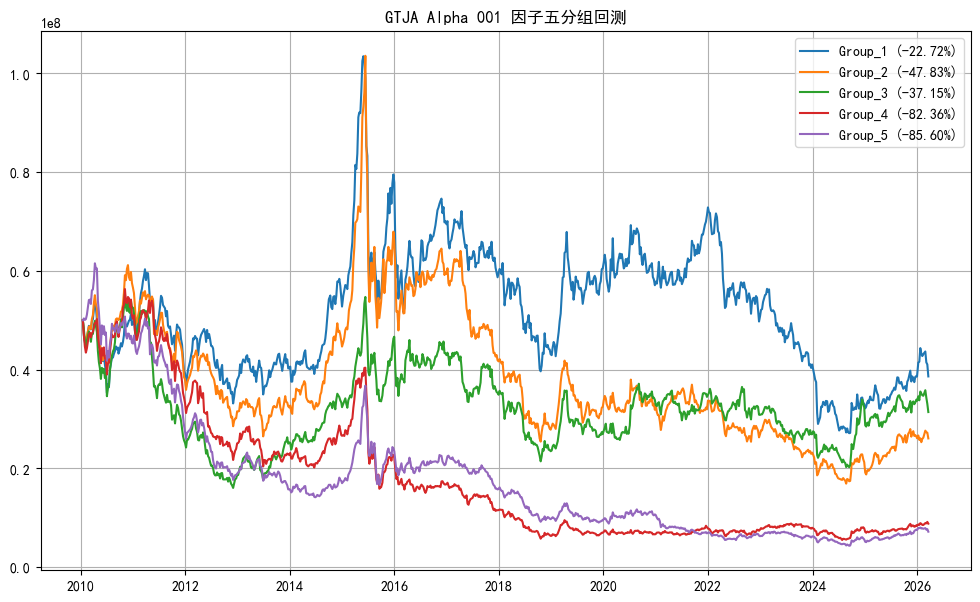

交易明细已保存至: F:\self_quant\quant_gemini\csv\gtja_191_alphas_trades.csv


In [17]:
plt.figure(figsize=(12, 7))
summary = []

for group_name, account in accounts.items():
    assets_df = pd.DataFrame(account.history_assets).set_index('date')
    if assets_df.empty: continue
    
    final_val = assets_df['total_asset'].iloc[-1]
    ret = (final_val - INITIAL_CASH) / INITIAL_CASH * 100
    
    # 收益统计
    logs = pd.DataFrame(account.trade_logs)
    fwd_stats = logs[logs['方向'] == '买入'][['未来1天收益', '未来1周收益', '未来1月收益']].mean() * 100
    
    summary.append({
        '分组': group_name, '最终资产': final_val, '总收益率(%)': ret,
        '1d前向收益(%)': fwd_stats['未来1天收益'], '1w前向收益(%)': fwd_stats['未来1周收益'], '1m前向收益(%)': fwd_stats['未来1月收益']
    })
    
    plt.plot(assets_df.index, assets_df['total_asset'], label=f"{group_name} ({ret:.2f}%)")

print("\n--- 回测统计摘要 ---")
print(pd.DataFrame(summary))

plt.title("GTJA Alpha 001 因子五分组回测")
plt.legend()
plt.grid(True)
plt.show()

# 保存交易明细
all_trades = pd.concat([pd.DataFrame(acc.trade_logs) for acc in accounts.values()])
all_trades.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"交易明细已保存至: {OUTPUT_CSV}")